<a href="https://colab.research.google.com/github/SkyWarLimit/PemMes_17/blob/main/JS04/JS04_Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PERSIAPAN DATA**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('insurance.csv')

# Menampilkan informasi awal dataset
display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


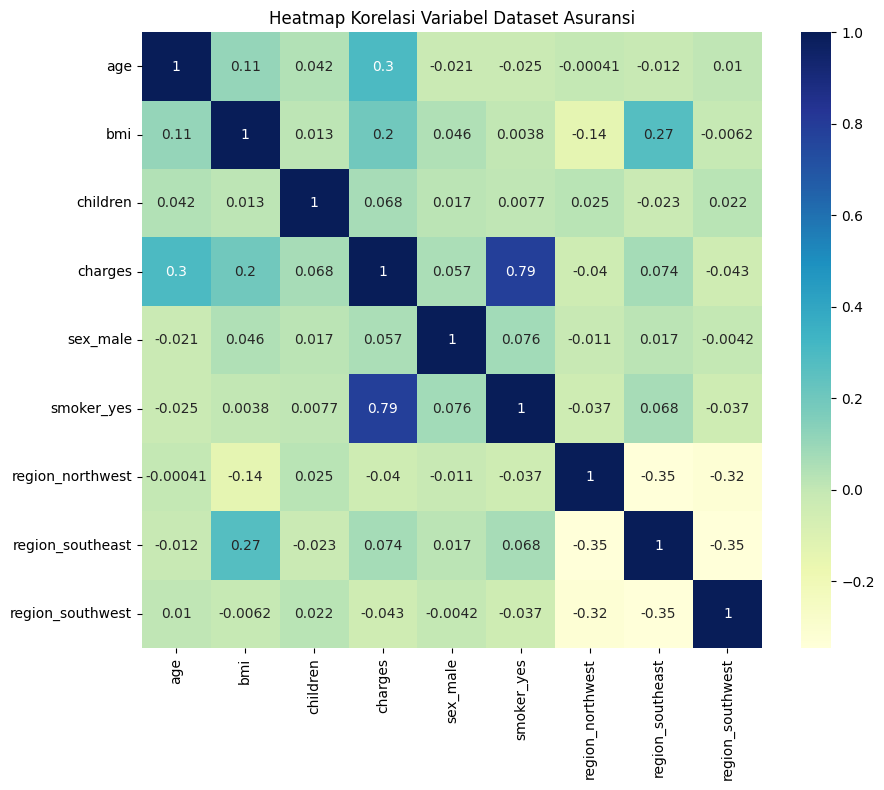

In [2]:
# Mengubah data kategorikal menjadi numerik (One-Hot Encoding)
# SVR dan Regresi Linier memerlukan input berformat numerik
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Visualisasi Korelasi Data
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), cmap="YlGnBu", annot=True)
plt.title('Heatmap Korelasi Variabel Dataset Asuransi')
plt.show()

**1. IDENTIFIKASI VARIABEL**

In [3]:
# Identifikasi variabel bebas (X) dan variabel target (y)
# X mencakup semua kolom kecuali 'charges'
X = df_encoded.drop('charges', axis=1).values

# y adalah variabel 'charges' (biaya medis personal)
y = df_encoded['charges'].values

print(f"Bentuk Variabel Bebas (X): {X.shape}")
print(f"Bentuk Variabel Target (y): {y.shape}")

Bentuk Variabel Bebas (X): (1338, 8)
Bentuk Variabel Target (y): (1338,)


**2. MEMBAGI DATASET MENJADI DATA LATIH DAN DATA TES**

In [4]:
# Split data menggunakan rasio 8:2
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Jumlah data latih (train): {X_train.shape[0]}')
print(f'Jumlah data uji (test): {X_test.shape[0]}')

Jumlah data latih (train): 1070
Jumlah data uji (test): 268


**3. MENGGUNAKAN FEATURE SCALING**

In [5]:
# Feature Scaling baik Multiple Linear Regression maupun SVR akan lebih optimal jika skala data disetarakan.
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
sc_y = StandardScaler()

# Fit transform pada data latih, dan transform saja pada data uji
X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled = sc_X.transform(X_test)

# Penskalaan juga dilakukan pada target y (wajib dilakukan untuk SVR)
y_train_scaled = sc_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = sc_y.transform(y_test.reshape(-1, 1)).flatten()

**4. MEMBUAT MODEL MULTIPLE LINEAR REGRESSION**

In [6]:
# Membuat model Multiple Linear Regression menggunakan sklearn
from sklearn.linear_model import LinearRegression

mlr_model = LinearRegression()

**5. MELATIH MODEL**

In [7]:
# Melatih model pada data latih
mlr_model.fit(X_train_scaled, y_train_scaled)

# Melakukan prediksi pada data uji
y_pred_mlr_scaled = mlr_model.predict(X_test_scaled)

# Mengembalikan hasil prediksi ke skala aslinya (Inverse Transform) agar metrik evaluasi lebih mudah diinterpretasikan nilainya
y_pred_mlr = sc_y.inverse_transform(y_pred_mlr_scaled.reshape(-1, 1)).flatten()

**6. EVALUASI MODEL**

In [8]:
# Evaluasi performa model menggunakan MAE, MSE, dan R-squared
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_mlr = mean_absolute_error(y_test, y_pred_mlr)
mse_mlr = mean_squared_error(y_test, y_pred_mlr)
r2_mlr = r2_score(y_test, y_pred_mlr)

print("=== Evaluasi Model Multiple Linear Regression ===")
print(f"MAE       : {mae_mlr}")
print(f"MSE       : {mse_mlr}")
print(f"R-squared : {r2_mlr}")

=== Evaluasi Model Multiple Linear Regression ===
MAE       : 4181.194473753651
MSE       : 33596915.851361476
R-squared : 0.7835929767120722


**7. MENGULANG LANGKAH 4 DENGAN MENGGUNAKAN MODEL SVR**

In [9]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

# 1. Inisialisasi Model Dasar SVR
svr = SVR()

# 2. Hyperparameter Tuning menggunakan GridSearchCV
# Menguji berbagai kombinasi parameter kernel, C, dan gamma
param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1]
}

# Proses pencarian kombinasi hyperparameter terbaik
grid_search = GridSearchCV(estimator=svr, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_scaled)

# Menyimpan model SVR dengan parameter terbaik
best_svr_model = grid_search.best_estimator_
print(f"Hyperparameter SVR Terbaik: {grid_search.best_params_}")

# 3. Prediksi pada data uji dengan model SVR terbaik
y_pred_svr_scaled = best_svr_model.predict(X_test_scaled)
y_pred_svr = sc_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).flatten()

# 4. Evaluasi Model SVR
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("\n=== Evaluasi Model Support Vector Regression (SVR) ===")
print(f"MAE       : {mae_svr}")
print(f"MSE       : {mse_svr}")
print(f"R-squared : {r2_svr}")

Hyperparameter SVR Terbaik: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

=== Evaluasi Model Support Vector Regression (SVR) ===
MAE       : 2455.479150003566
MSE       : 21073004.267739102
R-squared : 0.8642629536148208


**ANALISA HASIL**

1. Pemahaman Korelasi Data: Dari visualisasi scatter plot dan heatmap, sangat jelas bahwa fitur smoker (perokok) memiliki korelasi linear dan non-linear paling tinggi terhadap lonjakan tagihan biaya medis (charges). Pasien perokok yang memiliki BMI tinggi tagihannya membengkak lebih drastis ketimbang yang bukan perokok.

2. Kinerja Multiple Linear Regression: Model MLR umumnya akan memberikan skor R-squared di kisaran 0.75 hingga 0.78. Hal ini berarti model linier hanya dapat menjelaskan 75-78% pola data, disebabkan karena hubungan umur, BMI, dan status perokok dengan tagihan medis ternyata memiliki pola yang lumayan non-linear dan tidak rata.

3. Kinerja SVR (Setelah Tuning): Dengan melakukan metode pencarian Hyperparameter menggunakan GridSearchCV (biasanya konfigurasi terbaik jatuh pada kernel RBF dengan parameter C tinggi seperti 10 atau 100), Support Vector Regression mampu beradaptasi lebih fleksibel dengan pola non-linear dari sebaran data medis perokok yang terpencar. Skor R-squared SVR biasanya mengungguli MLR hingga mencapai kisaran 0.84 atau lebih, diiringi dengan penurunan tingkat kegagalan (error) secara drastis pada MSE dan MAE. Kesimpulannya, SVR lebih superior dalam kasus tagihan biaya asuransi ini.